# Preprocessing of psoriasis xenium data to run mintflow

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import anndata as ad
import os
import gc

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('annd

In [3]:
path = "/nfs/team361/cl35/DatasetPsoriasis/"
save_dir = "/nfs/team361/ms83/data/skin/psoriasis/"

## Section 1

In [11]:
adata = sc.read_h5ad(path + 'CE3-SKI-24-FO-1-S22-A1_Lesional_Psoriasis.h5ad')

In [12]:
adata

AnnData object with n_obs × n_vars = 22700 × 5000
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4',

In [13]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,lvl5_annotation_new12,lvl5_annotation_new13,baseline_severity,temp,Site_status_archive,response,response_binned,tmp,niche12_archive,gpfinder_populations
aaakigoi-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,aaakigoi-1,778.756531,1146.701294,10,0,0,0,0,0,10.0,...,Nonspecific,Nonspecific,NaN,NaN,Lesional,NaN,NaN,NaN,Reticular_dermis,ignore
aabbkpkh-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,aabbkpkh-1,570.767395,2037.670654,211,0,0,0,0,1,211.0,...,VE3_Ven,VE3_Ven,NaN,NaN,Lesional,NaN,NaN,NaN,Small_BV,VE3_Ven
aabdlobl-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,aabdlobl-1,592.748779,2089.008057,675,0,0,0,0,1,675.0,...,VE1_Art,VE1_Art,NaN,NaN,Lesional,NaN,NaN,NaN,Small_BV,Vasc endothelium
aabeobee-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,aabeobee-1,586.489807,2017.983887,361,0,0,0,0,0,361.0,...,VE3_Ven,VE3_Ven,NaN,NaN,Lesional,NaN,NaN,NaN,Small_BV,VE3_Ven
aabkbmib-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,aabkbmib-1,574.612610,2060.923096,404,0,0,0,0,0,404.0,...,VE3_Ven,VE3_Ven,NaN,NaN,Lesional,NaN,NaN,NaN,Small_BV,VE3_Ven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oipokmfc-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,oipokmfc-1,2490.263184,2084.955566,79,0,0,0,0,0,79.0,...,Pericyte1,Pericyte1,NaN,NaN,Lesional,NaN,NaN,NaN,Papillary_dermis,Pericyte
oippognm-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,oippognm-1,2306.990723,2050.717041,203,0,0,0,0,0,203.0,...,cDC2,cDC2,NaN,NaN,Lesional,NaN,NaN,NaN,Papillary_dermis,DC
ojaachem-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,ojaachem-1,2312.429443,2056.910645,45,0,0,0,0,0,45.0,...,F2: Universal,F2: Universal,NaN,NaN,Lesional,NaN,NaN,NaN,Papillary_dermis,Fibroblast
ojackeee-1_output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447,ojackeee-1,2315.941162,2052.734375,108,0,0,0,0,0,108.0,...,F1: Superficial,F1: Superficial,NaN,NaN,Lesional,NaN,NaN,NaN,Papillary_dermis,Fibroblast


In [14]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


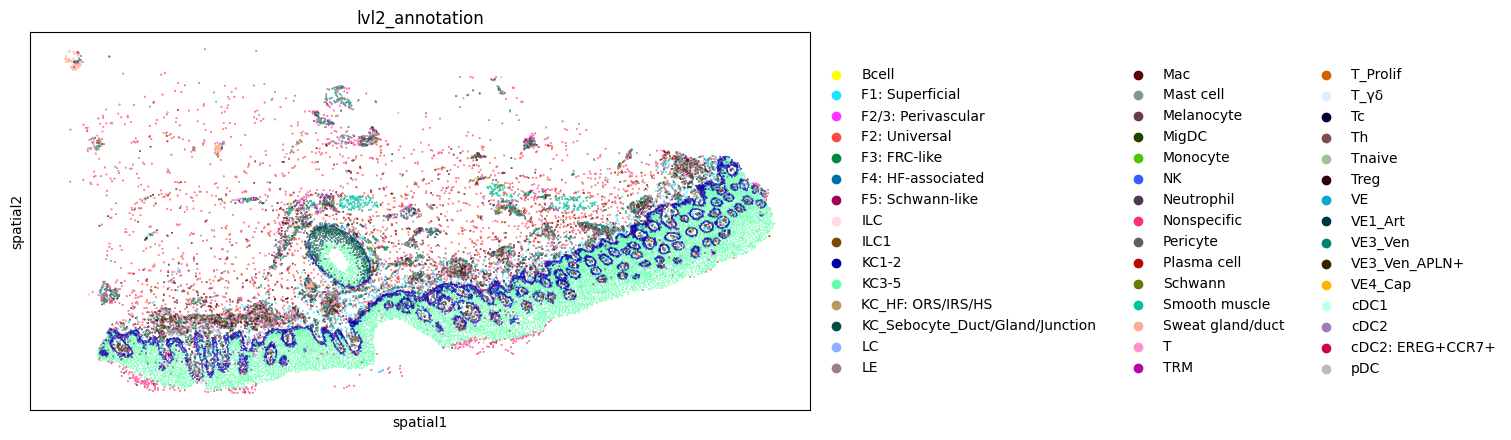

In [15]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "lvl2_annotation",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(15, 15)
)

In [16]:
adata.write_h5ad(save_dir + "CE3-SKI-24-FO-1-S22-A1_Lesional_Psoriasis_rawformintflow.h5ad")

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


## Section 2

In [17]:
adata = sc.read_h5ad(path + 'CE4-SKI-27-FO-4-S22-A2_Lesional_Psoriasis.h5ad')

In [18]:
adata

AnnData object with n_obs × n_vars = 21715 × 5000
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4',

In [19]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,lvl5_annotation_new12,lvl5_annotation_new13,baseline_severity,temp,Site_status_archive,response,response_binned,tmp,niche12_archive,gpfinder_populations
aaabngek-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,aaabngek-1,1435.907104,2079.553711,267,0,0,0,0,0,267.0,...,Adipocyte,Adipocyte,NaN,NaN,Lesional,NaN,NaN,NaN,Hypodermis,ignore
aaadnhgo-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,aaadnhgo-1,783.864990,3834.501709,25,0,0,0,0,0,25.0,...,Nonspecific,Nonspecific,NaN,NaN,Lesional,NaN,NaN,NaN,Reticular_dermis_LErich,ignore
aaaehjab-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,aaaehjab-1,1601.739380,2065.769043,727,0,0,0,0,0,727.0,...,Sweat gland,Sweat gland,NaN,NaN,Lesional,NaN,NaN,NaN,Sweat_gland,Sweat gland
aaapfomm-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,aaapfomm-1,1649.829834,2034.187256,544,0,0,0,0,0,544.0,...,F2/3: Perivascular,F2/3: Perivascular,NaN,NaN,Lesional,NaN,NaN,NaN,Small_BV,Fibroblast
aaapldol-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,aaapldol-1,1636.134644,2069.473389,525,0,0,0,0,0,525.0,...,Sweat gland,Sweat gland,NaN,NaN,Lesional,NaN,NaN,NaN,Sweat_gland,Sweat gland
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oinngmnp-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,oinngmnp-1,3030.809082,1020.266296,40,0,0,0,0,0,40.0,...,T,T,NaN,NaN,Lesional,NaN,NaN,NaN,Papillary_dermis,ignore
oinnhghl-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,oinnhghl-1,2537.882812,1187.883057,25,0,0,0,0,0,25.0,...,T,T,NaN,NaN,Lesional,NaN,NaN,NaN,Reticular_dermis_LErich,ignore
oinnnfoa-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,oinnnfoa-1,2693.925537,1145.865601,36,0,0,0,0,0,36.0,...,Nonspecific,Nonspecific,NaN,NaN,Lesional,NaN,NaN,NaN,OuterHF,ignore
oioccioc-1_output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447,oioccioc-1,2674.602051,1154.853760,48,0,0,0,0,0,48.0,...,Mast cell,Mast cell,NaN,NaN,Lesional,NaN,NaN,NaN,Reticular_dermis_LErich,Mast cell


In [20]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


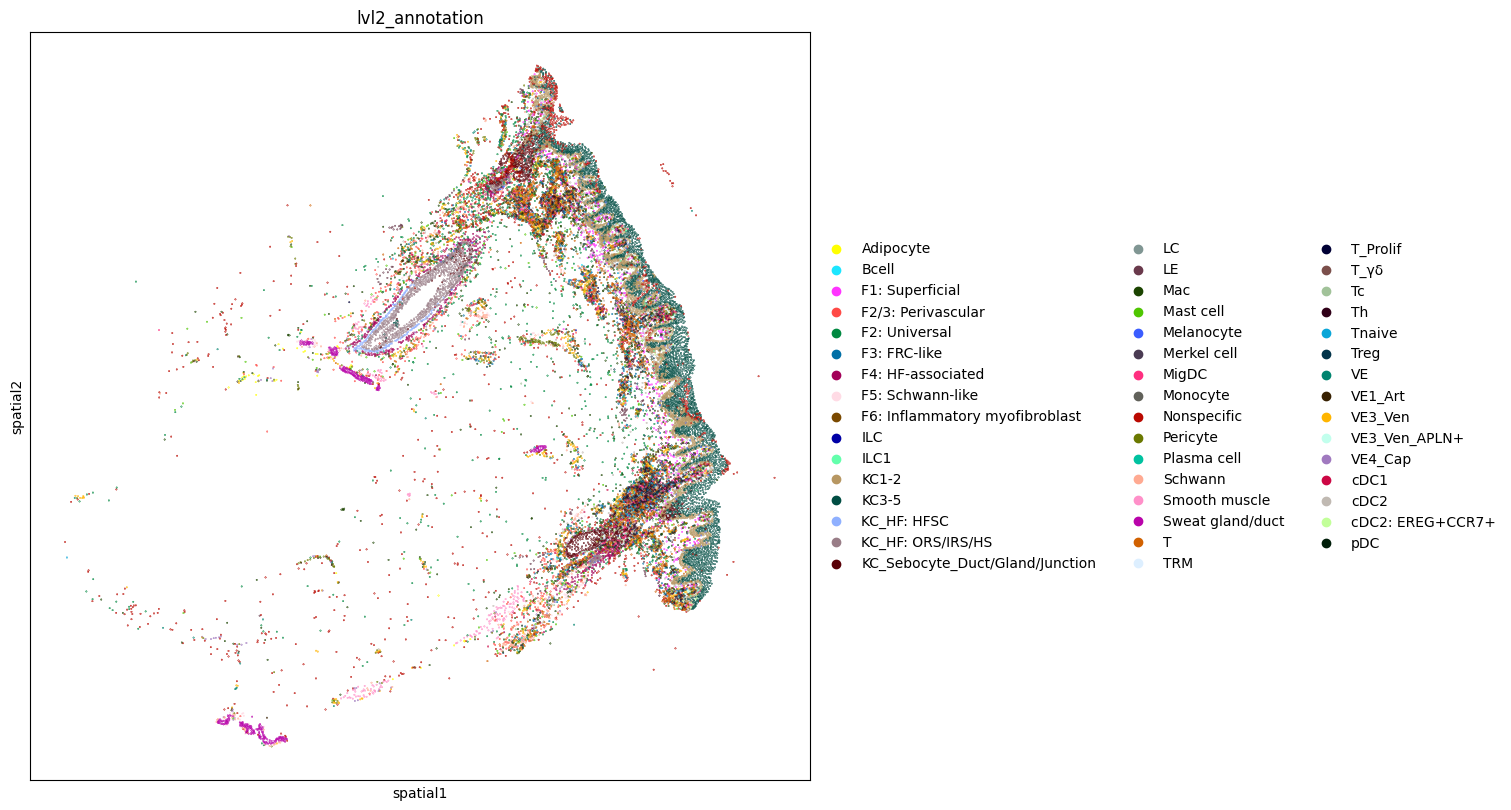

In [21]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "lvl2_annotation",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(15, 15)
)

In [22]:
adata.write_h5ad(save_dir + "CE4-SKI-27-FO-4-S22-A2_Lesional_Psoriasis_rawformintflow.h5ad")

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


## Section 3

In [23]:
adata = sc.read_h5ad(path + 'CE5-SKI-28-FO-1-S22-A1_Lesional_Psoriasis.h5ad')

In [24]:
adata

AnnData object with n_obs × n_vars = 13261 × 5000
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4',

In [25]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,lvl5_annotation_new12,lvl5_annotation_new13,baseline_severity,temp,Site_status_archive,response,response_binned,tmp,niche12_archive,gpfinder_populations
aaamelfd-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,aaamelfd-1,717.874695,2193.408936,381,0,0,0,0,0,381.0,...,KC5,KC5,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,KC
aabbljkj-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,aabbljkj-1,722.398804,2104.007324,281,0,0,0,0,0,281.0,...,KC5,KC5,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,KC
aabplkjl-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,aabplkjl-1,717.464172,2202.551025,351,0,0,0,0,0,351.0,...,KC5,KC5,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,KC
aackmjlo-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,aackmjlo-1,760.855469,2245.645264,508,1,0,0,0,1,508.0,...,KCinflamm,KCinflamm,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,ignore
aackpnkg-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,aackpnkg-1,790.462952,2263.042725,485,2,0,0,0,3,485.0,...,KCinflamm,KCinflamm,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,ignore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ohoipgkl-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,ohoipgkl-1,1618.368286,1367.634888,11,0,0,0,0,0,11.0,...,Nonspecific,Nonspecific,NaN,NaN,Lesional,NaN,NaN,NaN,Reticular_dermis_LErich,ignore
ohomkkme-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,ohomkkme-1,1615.323730,730.305603,11,0,0,0,0,0,11.0,...,Nonspecific,Nonspecific,NaN,NaN,Lesional,NaN,NaN,NaN,Reticular_dermis_LErich,ignore
ohpfcjnn-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,ohpfcjnn-1,1623.477417,727.624634,67,0,0,0,0,0,67.0,...,F2: Universal,F2: Universal,NaN,NaN,Lesional,NaN,NaN,NaN,Reticular_dermis_LErich,Fibroblast
oiammblf-1_output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447,oiammblf-1,1142.097656,1014.858032,14,0,0,0,0,0,14.0,...,Nonspecific,Nonspecific,NaN,NaN,Lesional,NaN,NaN,NaN,Small_BV,ignore


In [26]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


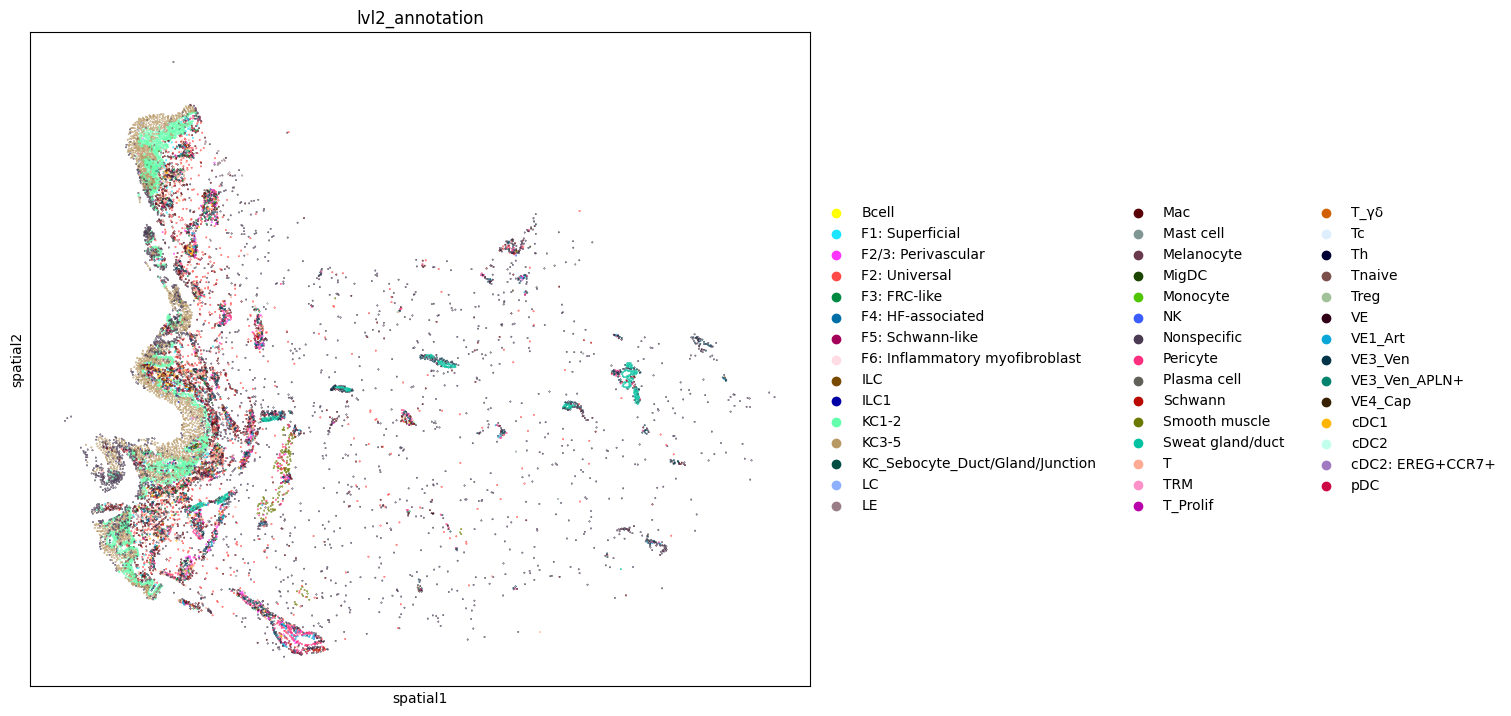

In [27]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "lvl2_annotation",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(15, 15)
)

In [28]:
adata.write_h5ad(save_dir + "CE5-SKI-28-FO-1-S22-A1_Lesional_Psoriasis_rawformintflow.h5ad")

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


## Section 4

In [29]:
adata = sc.read_h5ad(path + 'CE6-SKI-28-FO-4-S22-A1_Lesional_Psoriasis.h5ad')

In [30]:
adata

AnnData object with n_obs × n_vars = 9287 × 5000
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4', 

In [31]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,lvl5_annotation_new12,lvl5_annotation_new13,baseline_severity,temp,Site_status_archive,response,response_binned,tmp,niche12_archive,gpfinder_populations
aaacdnlk-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,aaacdnlk-1,537.299316,2054.501465,1249,0,0,0,0,2,1249.0,...,KCinflamm,KCinflamm,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,ignore
aaaclill-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,aaaclill-1,551.228882,2036.242554,1121,0,0,0,0,2,1121.0,...,KC1-2_cycling,KC1-2_cycling,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,KC
aaahpppp-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,aaahpppp-1,535.698608,2077.236328,1020,0,0,0,0,3,1020.0,...,KC5,KC5,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,KC
aabfjodp-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,aabfjodp-1,545.636230,2077.170654,1570,0,0,0,0,10,1570.0,...,KCinflamm,KCinflamm,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,ignore
aabhakhi-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,aabhakhi-1,544.897949,2062.505615,1236,0,0,0,0,3,1236.0,...,KCinflamm,KCinflamm,NaN,NaN,Lesional,NaN,NaN,NaN,Epidermis_mid2,ignore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oijhhcgd-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,oijhhcgd-1,1922.251587,2363.197998,211,0,0,0,0,0,211.0,...,Smooth muscle,Smooth muscle,NaN,NaN,Lesional,NaN,NaN,NaN,Muscle,ignore
oikdhhod-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,oikdhhod-1,1949.395630,2357.225586,152,0,0,0,0,0,152.0,...,Smooth muscle,Smooth muscle,NaN,NaN,Lesional,NaN,NaN,NaN,Muscle,ignore
oikmdgif-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,oikmdgif-1,1969.868164,2353.891357,148,0,0,0,0,0,148.0,...,Smooth muscle,Smooth muscle,NaN,NaN,Lesional,NaN,NaN,NaN,Muscle,ignore
oilcmeia-1_output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447,oilcmeia-1,1955.083008,2350.228516,227,0,0,0,0,0,227.0,...,Smooth muscle,Smooth muscle,NaN,NaN,Lesional,NaN,NaN,NaN,Muscle,ignore


In [32]:
if "counts" in adata.layers:
    print("Raw counts are stored in adata.layers['counts']")

Raw counts are stored in adata.layers['counts']


/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


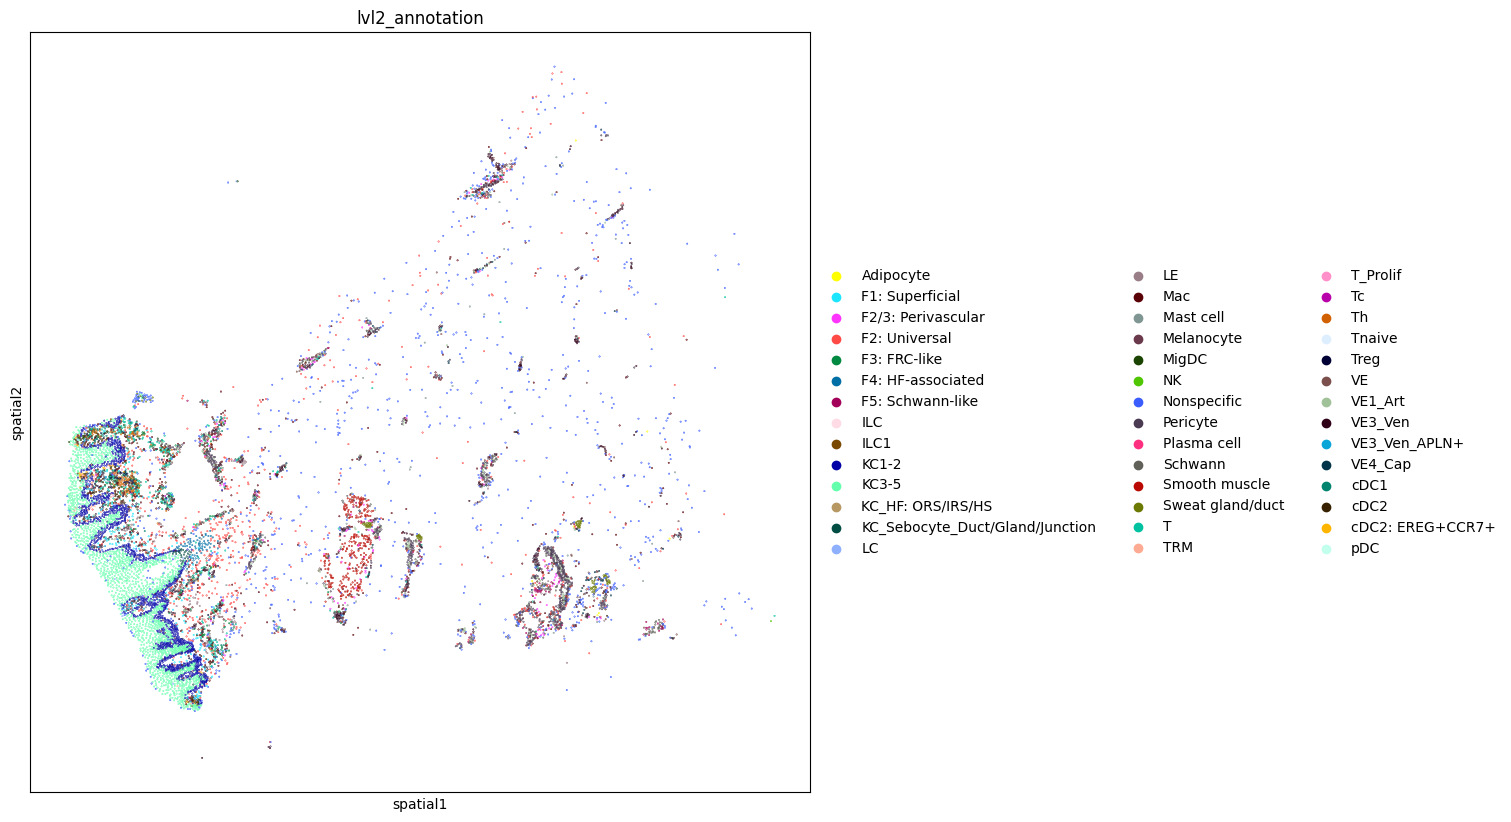

In [33]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "lvl2_annotation",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(15, 15)
)

In [34]:
adata.write_h5ad(save_dir + "CE6-SKI-28-FO-4-S22-A1_Lesional_Psoriasis_rawformintflow.h5ad")

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
